# Benchmark - [Nvidia's Nemotron 3.5 Lightning 30B](https://huggingface.co/unsloth/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-GGUF)

**Evaluation:** Tasks 01-06, excl. 03

**Hardware:** Apple M5 Max 128GB

In [1]:
import textwrap

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from benchmark_lib import (
  DATA_DIR,
  RUNS_PER_BATCH,
  SERIES,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  plot_timeouts,
  save_runs,
)

HARDWARE = "Apple M5 Max 128GB"
MODEL_LABEL = "Nemotron 3.5"


In [2]:
MODEL_NAME = "nemotron-3.5-lightning-30b-a3b"
benchmark_dir = DATA_DIR / "nvidia" / MODEL_NAME

if (not benchmark_dir.exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir, redact=("openai",))


In [3]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260815_105715,2026-08-15 10:57:15.768587,True,0.6,3.0,5,False,True,249,...,Nemotron-3.5-Lightning-30B-A3B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",21635,19749,1019881,0,1061265
1,01-data-loading,20260815_110125,2026-08-15 11:01:25.702961,True,0.8,4.0,5,False,True,2060,...,Nemotron-3.5-Lightning-30B-A3B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",34250,17512,420406,0,472168
2,01-data-loading,20260815_113546,2026-08-15 11:35:46.680376,True,1.0,5.0,5,True,True,302,...,Nemotron-3.5-Lightning-30B-A3B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",65021,16906,694091,0,776018
3,01-data-loading,20260815_114049,2026-08-15 11:40:49.176388,True,1.0,5.0,5,True,True,177,...,Nemotron-3.5-Lightning-30B-A3B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",18261,13963,628037,0,660261
4,01-data-loading,20260815_114347,2026-08-15 11:43:47.299682,True,0.6,3.0,5,False,True,347,...,Nemotron-3.5-Lightning-30B-A3B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",81243,18243,1163709,0,1263195


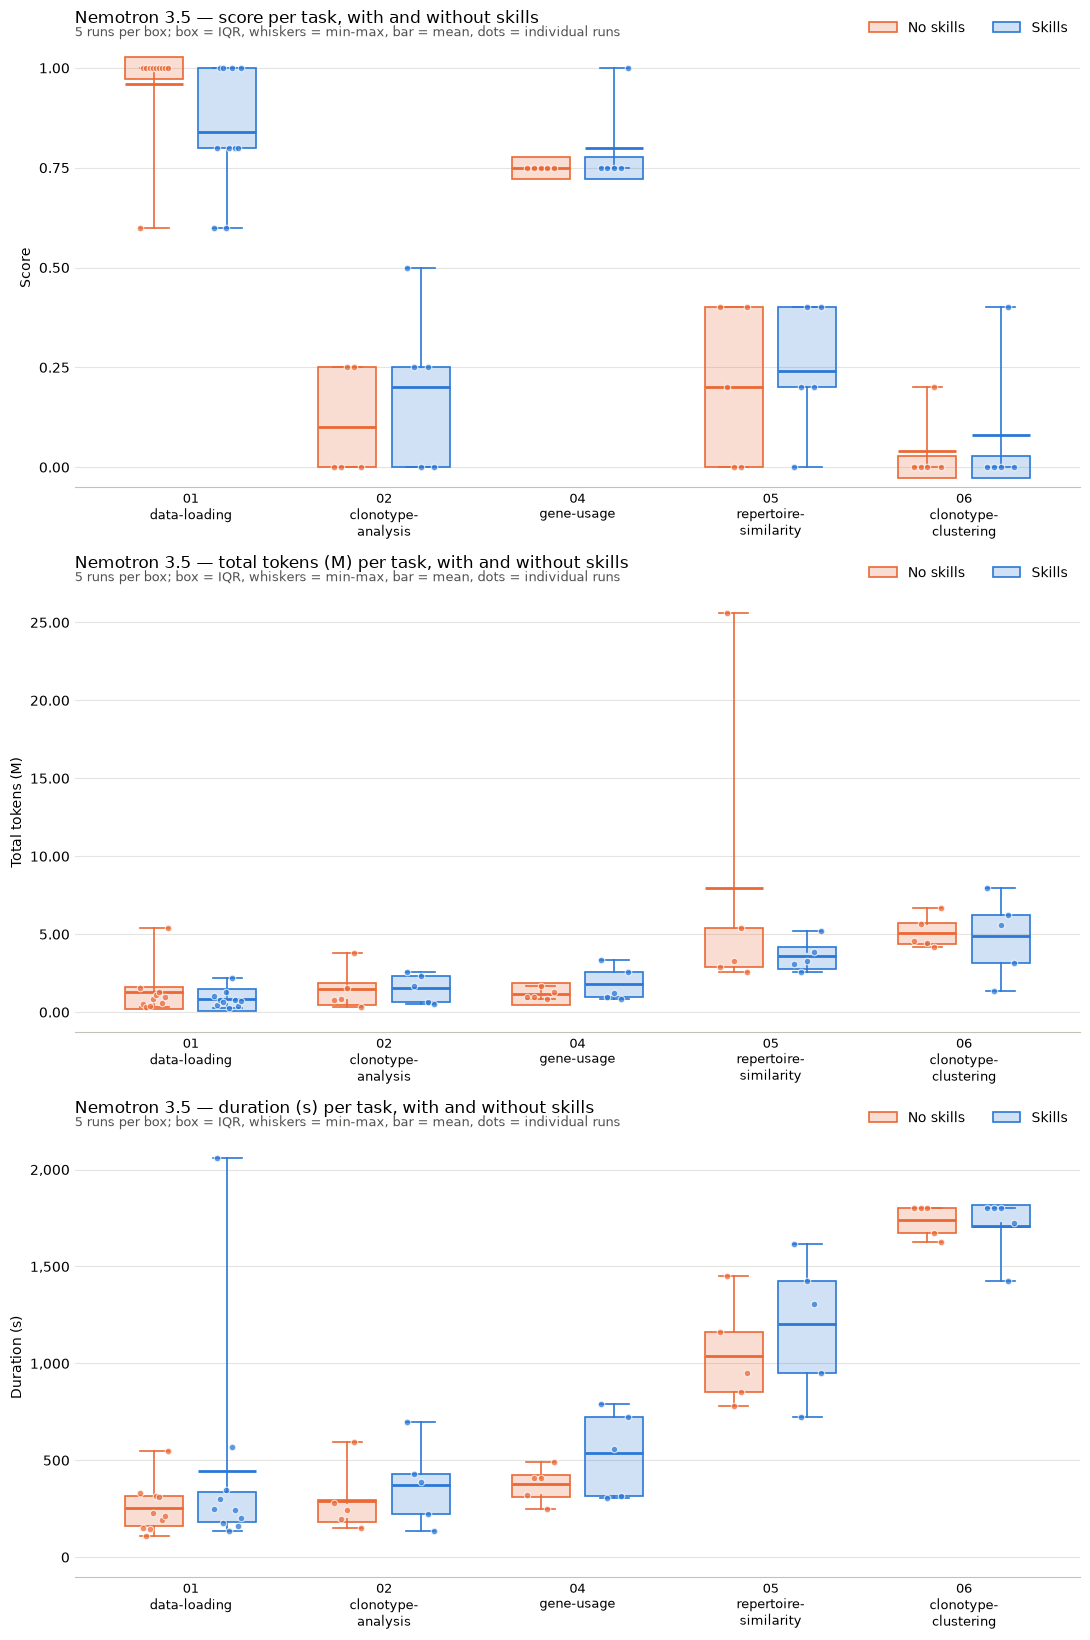

In [4]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


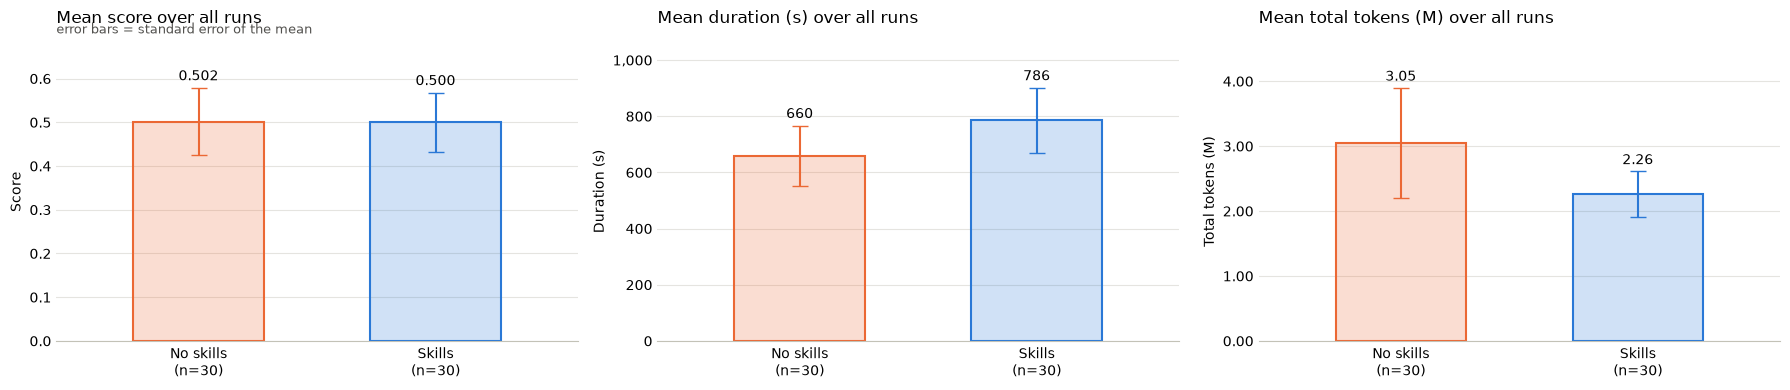

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [6]:
significance = compare_skills(benchmark)


In [7]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,30 vs 30,0.501667,0.500,-0.001667,0.993992,NaN,False
1,01-data-loading,Mann-Whitney U,10 vs 10,0.960000,0.840,-0.120000,0.044395,0.221973,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.100000,0.200,0.100000,0.488422,0.814037,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,0.750000,0.800,0.050000,0.423711,0.814037,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.200000,0.240,0.040000,0.824848,1.000000,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.040000,0.080,0.040000,1.000000,1.000000,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,0.410000,0.432,0.022000,0.625000,NaN,False


In [8]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,30 vs 30,659.5,785.70,126.20,0.424424,NaN,False
1,01-data-loading,Mann-Whitney U,10 vs 10,255.0,444.30,189.30,0.570750,0.863095,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,291.8,373.40,81.60,0.690476,0.863095,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,376.6,538.80,162.20,0.420635,0.863095,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,1038.4,1203.80,165.40,0.547619,0.863095,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,1740.2,1709.60,-30.60,1.000000,1.000000,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,740.4,853.98,113.58,0.125000,NaN,False


In [9]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,30 vs 30,3.045792e+06,2.256964e+06,-788828.30,0.695215,NaN,False
1,01-data-loading,Mann-Whitney U,10 vs 10,1.299887e+06,8.652441e+05,-434642.60,0.520523,1.0,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,1.470769e+06,1.547827e+06,77058.60,0.841270,1.0,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,1.154459e+06,1.788179e+06,633720.60,0.690476,1.0,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,7.947939e+06,3.608210e+06,-4339728.80,0.841270,1.0,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,5.101814e+06,4.867079e+06,-234735.00,1.000000,1.0,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,3.394973e+06,2.535308e+06,-859665.44,0.625000,NaN,False


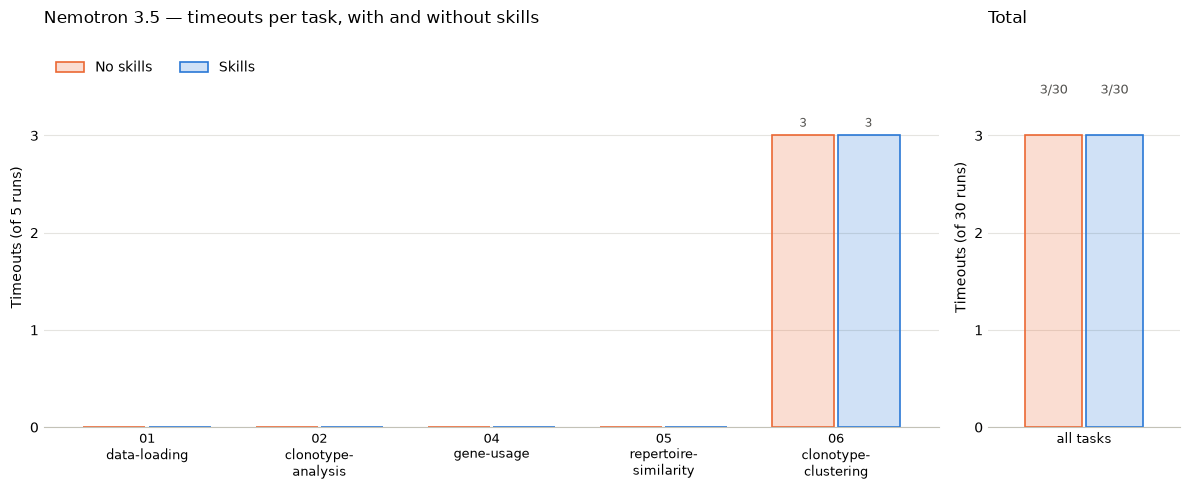

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_timeouts(benchmark, model_label=MODEL_LABEL, axs=axs)
fig.tight_layout()
plt.show()